In [42]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Ready')

Ready


## Step 1 — Load Existing NLP Features

In [43]:
DATASET_PATH = '../data/final/final_rl_dataset.csv'

df = pd.read_csv(DATASET_PATH)
print(f'Dataset shape       : {df.shape}  (tickets × features)')
print(f'Columns in dataset  : {df.shape[1]}')
print(f'\nAll columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:>2}. {col}')

Dataset shape       : (852, 40)  (tickets × features)
Columns in dataset  : 40

All columns:
   1. issue_number
   2. primary_label
   3. text_length
   4. word_count
   5. question_mark_flag
   6. has_solution_comment
   7. turn_count
   8. reassignment_count
   9. reopen_count
  10. resolution_success
  11. sla_breach_flag
  12. sla_remaining_norm
  13. sla_limit_hours
  14. interaction_depth
  15. first_response_time_hours
  16. intent_group
  17. confidence_score
  18. uncertainty_flag
  19. confidence_band
  20. rl_recommendation
  21. suggested_action
  22. urgency_score
  23. urgent_flag
  24. has_version
  25. has_error_type
  26. has_platform
  27. has_hardware
  28. entity_count
  29. missing_version
  30. missing_error
  31. missing_platform
  32. missing_hardware
  33. missing_count
  34. completeness_score
  35. needs_clarification
  36. clarification_priority
  37. sentiment_score
  38. sentiment_label
  39. frustration_level
  40. clean_text


## Step 2 — Overview of Existing NLP Features

In [44]:
# Group features by category
feature_groups = {
    'Ticket Meta'    : ['text_length', 'word_count', 'question_mark_flag', 'has_solution_comment', 'turn_count'],
    'SLA'            : ['sla_breach_flag', 'sla_remaining_norm', 'sla_limit_hours', 'interaction_depth'],
    'Intent'         : ['intent_group', 'confidence_score', 'uncertainty_flag', 'confidence_band'],
    'Urgency'        : ['urgency_score', 'urgent_flag'],
    'Entity'         : ['has_version', 'has_error_type', 'has_platform', 'has_hardware',
                        'entity_count', 'missing_count', 'completeness_score', 'reassignment_count'],
    'Clarification'  : ['needs_clarification', 'clarification_priority'],
    'Sentiment'      : ['sentiment_score', 'sentiment_label', 'frustration_level'],
    'Behavioral'     : ['rl_recommendation', 'reopen_count', 'resolution_success'],
}

print('=== NLP Feature Groups ===')
for group, cols in feature_groups.items():
    present = [c for c in cols if c in df.columns]
    print(f'\n  {group} ({len(present)} features):')
    for c in present:
        print(f'    {c:<30} | sample: {df[c].iloc[0]}')

=== NLP Feature Groups ===

  Ticket Meta (5 features):
    text_length                    | sample: 1634
    word_count                     | sample: 180
    question_mark_flag             | sample: 0
    has_solution_comment           | sample: 0
    turn_count                     | sample: 1

  SLA (4 features):
    sla_breach_flag                | sample: 0
    sla_remaining_norm             | sample: 0.9999
    sla_limit_hours                | sample: 72.0
    interaction_depth              | sample: 1

  Intent (4 features):
    intent_group                   | sample: duplicate
    confidence_score               | sample: 0.6989
    uncertainty_flag               | sample: 0
    confidence_band                | sample: medium

  Urgency (2 features):
    urgency_score                  | sample: 0.0257
    urgent_flag                    | sample: 0

  Entity (8 features):
    has_version                    | sample: 1
    has_error_type                 | sample: 0
    has_platfor

In [45]:
# Summary statistics for numeric NLP features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T[['mean', 'std', 'min', 'max']].round(4)

,mean,std,min,max
issue_number,221139.8498,79609.2859,99991.0000,303181.0000
text_length,1268.6690,1446.6469,8.0000,10146.0000
word_count,170.0129,171.8712,1.0000,1033.0000
question_mark_flag,0.3427,0.4749,0.0000,1.0000
has_solution_comment,0.3556,0.4790,0.0000,1.0000
turn_count,2.7007,6.2596,0.0000,151.0000
reassignment_count,0.7148,0.8684,0.0000,4.0000
reopen_count,0.0293,0.1757,0.0000,2.0000
resolution_success,0.3556,0.4790,0.0000,1.0000
sla_breach_flag,0.5129,0.5001,0.0000,1.0000


## Step 3 — Add RAG Signals


In [46]:
from nlp.nlp_pipeline import run_rag_for_dataframe

INDEX_PATH = '../data/retrieval/kb_index'

# Check index exists
if not os.path.exists(INDEX_PATH + '.faiss'):
    print('Index not found. Building now...')
    from retrieval.faiss_index import build_and_save_index
    build_and_save_index('../data/splits/knowledge_base.csv', INDEX_PATH)

print('Running RAG pipeline over all tickets...')
df_rag = run_rag_for_dataframe(
    df,
    text_col       = 'clean_text' if 'clean_text' in df.columns else 'issue_number',
    intent_col     = 'intent_group',
    confidence_col = 'confidence_score',
    top_k          = 5,
    index_path     = INDEX_PATH,
    show_progress  = True,
)

print(f'\nNew columns added: max_sim, avg_sim, sim_spread, knowledge_gap_flag')
print(f'New dataset shape: {df_rag.shape}')

Running RAG pipeline over all tickets...
  [RAG] Processing row 0/852 …
  [RAG] Processing row 100/852 …
  [RAG] Processing row 200/852 …
  [RAG] Processing row 300/852 …
  [RAG] Processing row 400/852 …
  [RAG] Processing row 500/852 …
  [RAG] Processing row 600/852 …
  [RAG] Processing row 700/852 …
  [RAG] Processing row 800/852 …

New columns added: max_sim, avg_sim, sim_spread, knowledge_gap_flag
New dataset shape: (852, 45)


## Step 4 — Full Feature Vector for Sample Tickets

In [47]:
# Show 3 sample tickets with all features including RAG signals
state_cols_display = [
    'issue_number', 'intent_group', 'confidence_score', 'urgency_score', 'urgent_flag',
    'sla_breach_flag', 'sla_remaining_norm', 'needs_clarification',
    'sentiment_score', 'frustration_level',
    'completeness_score', 'missing_count',
    # RAG signals ─────────────────────
    'max_sim', 'avg_sim', 'sim_spread', 'knowledge_gap_flag'
]

present_cols = [c for c in state_cols_display if c in df_rag.columns]
sample_view = df_rag[present_cols].head(3).copy()
sample_view

,issue_number,intent_group,confidence_score,urgency_score,urgent_flag,sla_breach_flag,sla_remaining_norm,needs_clarification,sentiment_score,frustration_level,completeness_score,missing_count,max_sim,avg_sim,sim_spread,knowledge_gap_flag
0,303181,duplicate,0.6989,0.0257,0,0,0.9999,0,0.7579,0.1210,1.0000,0,0.5141,0.5141,0.0000,1
1,303177,needs_info,0.5434,0.1360,0,0,0.9996,1,-0.2960,0.6480,1.0000,0,0.4165,0.4165,0.0000,1
2,303167,duplicate,0.7458,0.0193,0,0,0.9997,0,0.6715,0.1643,1.0000,0,0.5434,0.5434,0.0000,1


In [48]:
# Print a single ticket as a full feature list
from rl.state_builder import STATE_COLUMNS, INTENT_GROUP_MAP, CONFIDENCE_BAND_MAP, SENTIMENT_LABEL_MAP, RL_RECOMMENDATION_MAP

ticket_row = df_rag.iloc[0]
print('=== Full State Vector for Ticket #0 ===')
print(f'  Issue   : #{ticket_row.get("issue_number", "N/A")}')
print(f'  Intent  : {ticket_row.get("intent_group", "N/A")}')
print()

ENCODE_MAPS = {
    'intent_group_enc'     : INTENT_GROUP_MAP,
    'confidence_band_enc'  : CONFIDENCE_BAND_MAP,
    'sentiment_label_enc'  : SENTIMENT_LABEL_MAP,
    'rl_recommendation_enc': RL_RECOMMENDATION_MAP,
}

for col in STATE_COLUMNS:
    # Try direct or encoded
    raw_col = col.replace('_enc', '')
    if col in df_rag.columns:
        val = ticket_row[col]
    elif raw_col in df_rag.columns and col in ENCODE_MAPS:
        raw_val = str(ticket_row[raw_col]).lower().strip()
        val = ENCODE_MAPS[col].get(raw_val, '?')
    else:
        val = 'N/A'
    rag_tag = ' ← RAG' if col in ['max_sim','avg_sim','sim_spread','knowledge_gap_flag'] else ''
    print(f'  {col:<30} : {val}{rag_tag}')

=== Full State Vector for Ticket #0 ===
  Issue   : #303181
  Intent  : duplicate

  text_length                    : 1634
  word_count                     : 180
  question_mark_flag             : 0
  has_solution_comment           : 0
  turn_count                     : 1
  sla_breach_flag                : 0
  sla_remaining_norm             : 0.9999
  sla_limit_hours                : 72.0
  interaction_depth              : 1
  intent_group_enc               : 0
  confidence_score               : 0.6989
  uncertainty_flag               : 0
  confidence_band_enc            : 1
  urgency_score                  : 0.0257
  urgent_flag                    : 0
  has_version                    : 1
  has_error_type                 : 0
  has_platform                   : 1
  has_hardware                   : 1
  entity_count                   : 3
  missing_count                  : 0
  completeness_score             : 1.0
  reassignment_count             : 0
  needs_clarification            : 0
  cl

## Step 5 — Before vs After RAG Comparison

In [49]:
print('=== BEFORE RAG (NLP features only) ===')
before_cols = [c for c in df.columns if c not in ['max_sim','avg_sim','sim_spread','knowledge_gap_flag']]
print(f'  Number of features : {len(before_cols)}')
print(f'  Feature types : {df[before_cols].select_dtypes(include=[np.number]).shape[1]} numeric, '
      f'{df[before_cols].select_dtypes(exclude=[np.number]).shape[1]} categorical')

print()
print('=== AFTER RAG (NLP + retrieval signals) ===')
rag_new_cols = ['max_sim', 'avg_sim', 'sim_spread', 'knowledge_gap_flag']
print(f'  Number of features : {len(before_cols)} + 4 RAG = {len(before_cols)+4}')
print(f'  NEW features added :')
for col in rag_new_cols:
    if col in df_rag.columns:
        print(f'    {col:<28} | mean={df_rag[col].mean():.4f}  std={df_rag[col].std():.4f}')

=== BEFORE RAG (NLP features only) ===
  Number of features : 40
  Feature types : 33 numeric, 7 categorical

=== AFTER RAG (NLP + retrieval signals) ===
  Number of features : 40 + 4 RAG = 44
  NEW features added :
    max_sim                      | mean=0.7794  std=0.1979
    avg_sim                      | mean=0.6759  std=0.1406
    sim_spread                   | mean=0.1583  std=0.1513
    knowledge_gap_flag           | mean=0.1291  std=0.3355


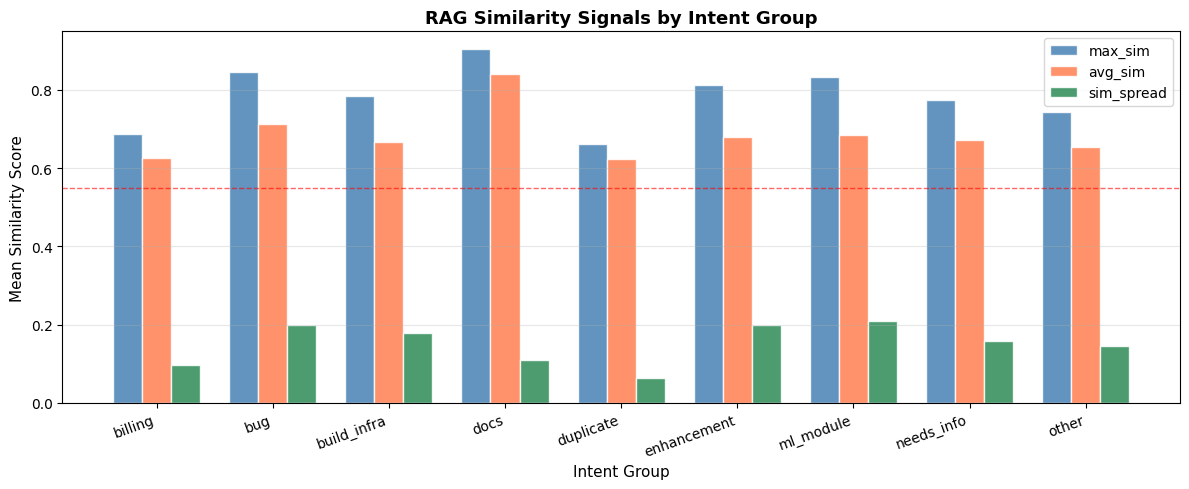

Plot saved → evaluation/reports/rag_signals_by_intent.png


In [50]:
# Bar chart: RAG signal means by intent group
rag_cols = [c for c in ['max_sim', 'avg_sim', 'sim_spread'] if c in df_rag.columns]

if 'intent_group' in df_rag.columns and rag_cols:
    group_means = df_rag.groupby('intent_group')[rag_cols].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(group_means))
    width = 0.25
    colors = ['steelblue', 'coral', 'seagreen']

    for i, (col, color) in enumerate(zip(rag_cols, colors)):
        ax.bar(x + i*width, group_means[col], width, label=col, color=color, alpha=0.85, edgecolor='white')

    ax.set_xlabel('Intent Group', fontsize=11)
    ax.set_ylabel('Mean Similarity Score', fontsize=11)
    ax.set_title('RAG Similarity Signals by Intent Group', fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(group_means.index, rotation=20, ha='right', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(0.55, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Gap threshold')

    plt.tight_layout()
    plt.savefig('../evaluation/reports/rag_signals_by_intent.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved → evaluation/reports/rag_signals_by_intent.png')

## Step 6 — Knowledge Gap by Intent Group

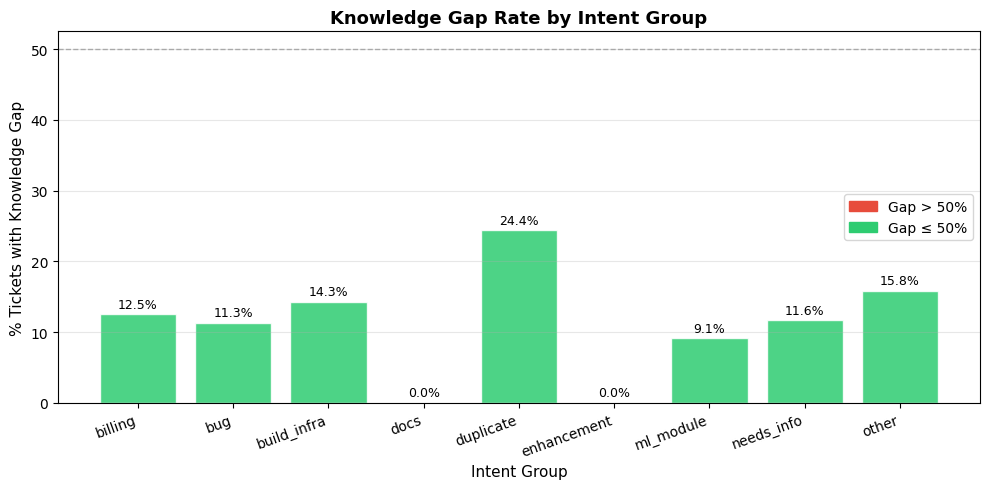

Plot saved → evaluation/reports/knowledge_gap_by_intent.png


In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
if 'knowledge_gap_flag' in df_rag.columns and 'intent_group' in df_rag.columns:
    gap_by_intent = df_rag.groupby('intent_group')['knowledge_gap_flag'].mean() * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#E74C3C' if v > 50 else '#2ECC71' for v in gap_by_intent.values]
    bars = ax.bar(gap_by_intent.index, gap_by_intent.values, color=colors, edgecolor='white', alpha=0.85)

    ax.set_xlabel('Intent Group', fontsize=11)
    ax.set_ylabel('% Tickets with Knowledge Gap', fontsize=11)
    ax.set_title('Knowledge Gap Rate by Intent Group', fontsize=13, fontweight='bold')
    ax.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    plt.xticks(rotation=20, ha='right', fontsize=10)

    for bar, val in zip(bars, gap_by_intent.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    red_patch   = mpatches.Patch(color='#E74C3C', label='Gap > 50%')
    green_patch = mpatches.Patch(color='#2ECC71', label='Gap ≤ 50%')
    ax.legend(handles=[red_patch, green_patch], fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../evaluation/reports/knowledge_gap_by_intent.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Plot saved → evaluation/reports/knowledge_gap_by_intent.png')

## Step 7 — Informal Feature Importance


In [52]:
importance_notes = [
    ('knowledge_gap_flag  ← NEW', 'Binary: no KB evidence → forces CLARIFY or ESCALATE'),
    ('max_sim             ← NEW', 'Primary KB confidence: high → can SUGGEST'),


    ('tier1_flag          ← NEW', 'Indicates verified KB solution; high trust for suggestion actions'),
    ('tier2_flag          ← NEW', 'Indicates weaker KB evidence; may require clarification before acting'),

    ('frustration_level',         'High frustration + gap → ESCALATE immediately'),
    ('sla_breach_flag',           'Breached SLA → highest urgency, skip clarification'),
    ('needs_clarification',       'NLP-derived: missing info → CLARIFY before routing'),
    ('confidence_score',          'High → trust intent and ROUTE; low → hedge'),
    ('urgency_score',             'Composite: low + high sim → SUGGEST calmly'),
    ('completeness_score',        'Low → key info missing, CLARIFY recommended'),
    ('sentiment_score',           'Very negative → add empathy to response action'),
    ('avg_sim             ← NEW', 'High avg_sim → multiple KB matches, strong evidence'),
]

print('=== Informal Feature Importance (RL Decision Perspective) ===')
print(f'{"Rank":<5} {"Feature":<35} {"Why it matters"}')
print('-' * 85)
for i, (feat, note) in enumerate(importance_notes, 1):
    print(f'{i:<5} {feat:<35} {note}')

=== Informal Feature Importance (RL Decision Perspective) ===
Rank  Feature                             Why it matters
-------------------------------------------------------------------------------------
1     knowledge_gap_flag  ← NEW           Binary: no KB evidence → forces CLARIFY or ESCALATE
2     max_sim             ← NEW           Primary KB confidence: high → can SUGGEST
3     tier1_flag          ← NEW           Indicates verified KB solution; high trust for suggestion actions
4     tier2_flag          ← NEW           Indicates weaker KB evidence; may require clarification before acting
5     frustration_level                   High frustration + gap → ESCALATE immediately
6     sla_breach_flag                     Breached SLA → highest urgency, skip clarification
7     needs_clarification                 NLP-derived: missing info → CLARIFY before routing
8     confidence_score                    High → trust intent and ROUTE; low → hedge
9     urgency_score                   

## Step 8 — Build Final State Matrix

In [53]:
from rl.state_builder import build_state_vectors

# Full pipeline
df_final, state_matrix = build_state_vectors(
    dataset_path = '../data/final/final_rl_dataset.csv',
    index_path   = '../data/retrieval/kb_index',
    output_path  = '../data/final/rl_ready_dataset.csv',
    top_k        = 5,
    save         = True,
)

print(f'\nFinal state matrix shape : {state_matrix.shape}')
print(f'  → {state_matrix.shape[0]} tickets × {state_matrix.shape[1]} features')
print(f'  → dtype: {state_matrix.dtype}')
print(f'  → NaN count: {np.isnan(state_matrix).sum()}')

[StateBuilder] Loading dataset: ../data/final/final_rl_dataset.csv
[StateBuilder] 852 tickets loaded, 40 existing features.
[StateBuilder] Running RAG pipeline …
  [RAG] Processing row 0/852 …
  [RAG] Processing row 100/852 …
  [RAG] Processing row 200/852 …
  [RAG] Processing row 300/852 …
  [RAG] Processing row 400/852 …
  [RAG] Processing row 500/852 …
  [RAG] Processing row 600/852 …
  [RAG] Processing row 700/852 …
  [RAG] Processing row 800/852 …
[StateBuilder] RAG signals added: max_sim, avg_sim, sim_spread, knowledge_gap_flag.
[StateBuilder] State matrix shape: (852, 37)  (tickets × features)
[StateBuilder] Saved augmented dataset → ../data/final/rl_ready_dataset.csv

Final state matrix shape : (852, 37)
  → 852 tickets × 37 features
  → dtype: float32
  → NaN count: 0


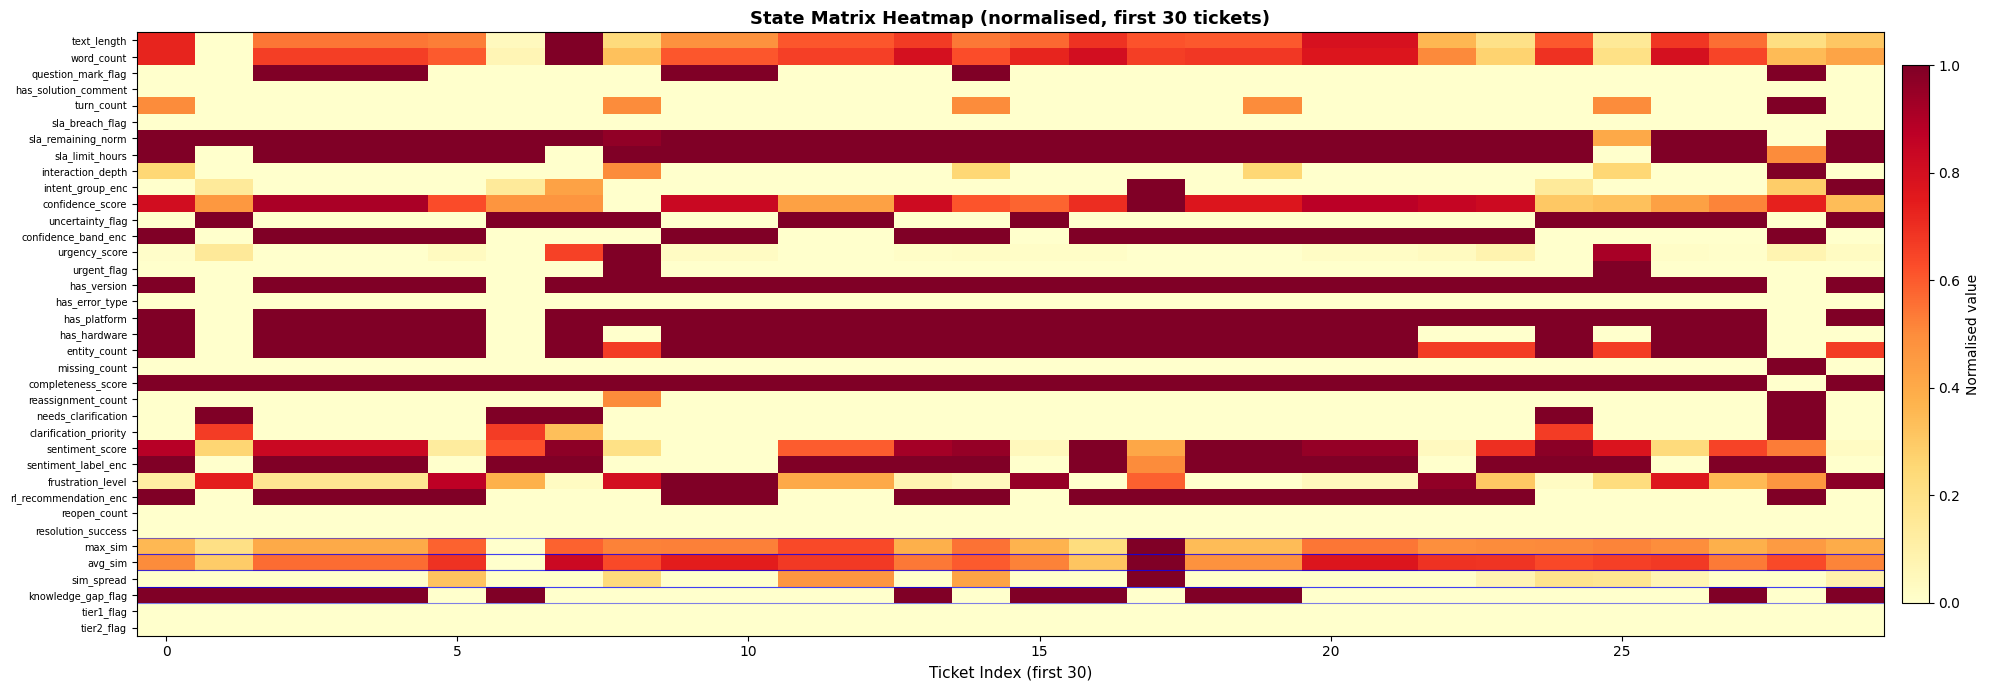

Plot saved → evaluation/reports/state_matrix_heatmap.png
Blue lines mark the 4 new RAG features.


In [54]:
# Heatmap of state matrix (sample rows)
from rl.state_builder import STATE_COLUMNS

sample_mat = state_matrix[:30, :]

# Normalise each column to [0,1] for display
mat_min  = sample_mat.min(axis=0, keepdims=True)
mat_max  = sample_mat.max(axis=0, keepdims=True)
mat_norm = np.where(mat_max - mat_min > 0, (sample_mat - mat_min) / (mat_max - mat_min + 1e-9), 0)

fig, ax = plt.subplots(figsize=(20, 7))
im = ax.imshow(mat_norm.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_yticks(range(len(STATE_COLUMNS)))
ax.set_yticklabels(STATE_COLUMNS, fontsize=7)
ax.set_xlabel('Ticket Index (first 30)', fontsize=11)
ax.set_title('State Matrix Heatmap (normalised, first 30 tickets)', fontsize=13, fontweight='bold')

# Highlight RAG features
rag_rows = [STATE_COLUMNS.index(c) for c in ['max_sim','avg_sim','sim_spread','knowledge_gap_flag'] if c in STATE_COLUMNS]
for row_idx in rag_rows:
    ax.axhline(row_idx - 0.5, color='blue', linewidth=0.8, alpha=0.5)
    ax.axhline(row_idx + 0.5, color='blue', linewidth=0.8, alpha=0.5)

plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01, label='Normalised value')
plt.tight_layout()
plt.savefig('../evaluation/reports/state_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → evaluation/reports/state_matrix_heatmap.png')
print('Blue lines mark the 4 new RAG features.')

In [55]:
from rl.state_builder import get_state_column_names
print(get_state_column_names())

['text_length', 'word_count', 'question_mark_flag', 'has_solution_comment', 'turn_count', 'sla_breach_flag', 'sla_remaining_norm', 'sla_limit_hours', 'interaction_depth', 'intent_group_enc', 'confidence_score', 'uncertainty_flag', 'confidence_band_enc', 'urgency_score', 'urgent_flag', 'has_version', 'has_error_type', 'has_platform', 'has_hardware', 'entity_count', 'missing_count', 'completeness_score', 'reassignment_count', 'needs_clarification', 'clarification_priority', 'sentiment_score', 'sentiment_label_enc', 'frustration_level', 'rl_recommendation_enc', 'reopen_count', 'resolution_success', 'max_sim', 'avg_sim', 'sim_spread', 'knowledge_gap_flag', 'tier1_flag', 'tier2_flag']


In [56]:
from rl.state_builder import build_state_vectors

df_aug, state_matrix = build_state_vectors(
    dataset_path="../data/final/final_rl_dataset.csv",
    index_path="../data/retrieval/kb_index",
    save=False
)

[StateBuilder] Loading dataset: ../data/final/final_rl_dataset.csv
[StateBuilder] 852 tickets loaded, 40 existing features.
[StateBuilder] Running RAG pipeline …
  [RAG] Processing row 0/852 …
  [RAG] Processing row 100/852 …
  [RAG] Processing row 200/852 …
  [RAG] Processing row 300/852 …
  [RAG] Processing row 400/852 …
  [RAG] Processing row 500/852 …
  [RAG] Processing row 600/852 …
  [RAG] Processing row 700/852 …
  [RAG] Processing row 800/852 …
[StateBuilder] RAG signals added: max_sim, avg_sim, sim_spread, knowledge_gap_flag.
[StateBuilder] State matrix shape: (852, 37)  (tickets × features)


In [57]:
row = df_aug.iloc[0]

for col in get_state_column_names():
    print(f"{col:30} = {row[col]}")

text_length                    = 1634
word_count                     = 180
question_mark_flag             = 0
has_solution_comment           = 0
turn_count                     = 1
sla_breach_flag                = 0
sla_remaining_norm             = 0.9999
sla_limit_hours                = 72.0
interaction_depth              = 1
intent_group_enc               = 0
confidence_score               = 0.6989
uncertainty_flag               = 0
confidence_band_enc            = 1
urgency_score                  = 0.0257
urgent_flag                    = 0
has_version                    = 1
has_error_type                 = 0
has_platform                   = 1
has_hardware                   = 1
entity_count                   = 3
missing_count                  = 0
completeness_score             = 1.0
reassignment_count             = 0
needs_clarification            = 0
clarification_priority         = 0
sentiment_score                = 0.7579
sentiment_label_enc            = 2
frustration_level        

In [58]:
print("RAG Features:")
print(df_aug[["max_sim","avg_sim","sim_spread","knowledge_gap_flag"]].head())

print("\nTier Features:")
print(df_aug[["top_tier","tier1_flag","tier2_flag"]].head())

RAG Features:
   max_sim  avg_sim  sim_spread  knowledge_gap_flag
0   0.5141   0.5141      0.0000                   1
1   0.4165   0.4165      0.0000                   1
2   0.5434   0.5434      0.0000                   1
3   0.5434   0.5434      0.0000                   1
4   0.5434   0.5434      0.0000                   1

Tier Features:
         top_tier  tier1_flag  tier2_flag
0  tier1_verified           1           0
1  tier1_verified           1           0
2  tier1_verified           1           0
3  tier1_verified           1           0
4  tier1_verified           1           0


In [59]:
print("State matrix shape:", state_matrix.shape)

State matrix shape: (852, 37)
